In [23]:
#Paso 1 - Improtar liberias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#manejar fechas
from datetime import datetime

#ml
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#data visualization
import plotly.express as px
import plotly.graph_objects as go

#dashboard

import streamlit as st

In [2]:
#Paso 2 - Cargar Data

!pip install openpyxl
data_path = "dataset/online_retail.xlsx"
df_raw = pd.read_excel(data_path)
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df_raw.shape

(541909, 8)

In [5]:
# Paso 3 Preprocessing 

df_baking = df_raw.copy()

#minusculas los titulos
df_baking.columns = df_baking.columns.str.lower()
df_baking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    541909 non-null  object        
 1   stockcode    541909 non-null  object        
 2   description  540455 non-null  object        
 3   quantity     541909 non-null  int64         
 4   invoicedate  541909 non-null  datetime64[ns]
 5   unitprice    541909 non-null  float64       
 6   customerid   406829 non-null  float64       
 7   country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
#quitar datos faltantes
df_baking = df_baking.dropna(subset=["customerid"])

#cambiar el type de customerid
df_baking["customerid"] = df_baking["customerid"].astype(str)
df_baking.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    406829 non-null  object        
 1   stockcode    406829 non-null  object        
 2   description  406829 non-null  object        
 3   quantity     406829 non-null  int64         
 4   invoicedate  406829 non-null  datetime64[ns]
 5   unitprice    406829 non-null  float64       
 6   customerid   406829 non-null  object        
 7   country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


In [7]:
df_baking["amount"] = df_baking["quantity"] * df_baking["unitprice"]
#df_baking = df_baking.rename(columns={'amounth': 'amount'}) #me equivoqué y renombré
df_baking.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    406829 non-null  object        
 1   stockcode    406829 non-null  object        
 2   description  406829 non-null  object        
 3   quantity     406829 non-null  int64         
 4   invoicedate  406829 non-null  datetime64[ns]
 5   unitprice    406829 non-null  float64       
 6   customerid   406829 non-null  object        
 7   country      406829 non-null  object        
 8   amount       406829 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 31.0+ MB


In [8]:
df_baking.describe().T

,count,mean,min,25%,50%,75%,max,std
quantity,406829.0,12.061303,-80995.0,2.0,5.0,12.0,80995.0,248.69337
invoicedate,406829,2011-07-10 16:30:57.879207424,2010-12-01 08:26:00,2011-04-06 15:02:00,2011-07-31 11:48:00,2011-10-20 13:06:00,2011-12-09 12:50:00,NaN
unitprice,406829.0,3.460471,0.0,1.25,1.95,3.75,38970.0,69.315162
amount,406829.0,20.401854,-168469.6,4.2,11.1,19.5,168469.6,427.591718


In [9]:
#agrupamiento 

df_monetary = df_baking.groupby('customerid')['amount'].sum().reset_index()
df_frequency = df_baking.groupby('customerid')["quantity"].count().reset_index()

max_date = df_baking['invoicedate'].max()

df_recency = df_baking.groupby('customerid')['invoicedate'].max().reset_index()
df_recency['recency_days'] = max_date - df_recency['invoicedate']
df_recency['recency_days'] = df_recency['recency_days'].dt.days #para acceder sólo a número de días


In [10]:
df_recency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customerid    4372 non-null   object        
 1   invoicedate   4372 non-null   datetime64[ns]
 2   recency_days  4372 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 102.6+ KB


In [11]:
df_recency.head()

,customerid,invoicedate,recency_days
0,12346.0,2011-01-18 10:17:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


In [12]:
#fusionar columnas

df_rfm = pd.merge(df_monetary, df_frequency, on='customerid', how='inner')
df_rfm = pd.merge(df_rfm, df_recency, on="customerid", how="inner")
df_rfm = df_rfm.rename(columns={'quantity': 'frequency', 'recency_days': 'recency'})
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customerid   4372 non-null   object        
 1   amount       4372 non-null   float64       
 2   frequency    4372 non-null   int64         
 3   invoicedate  4372 non-null   datetime64[ns]
 4   recency      4372 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 170.9+ KB


In [13]:
#modelo
rfm_model_df = df_rfm[['amount', 'frequency', 'recency']]
rfm_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amount     4372 non-null   float64
 1   frequency  4372 non-null   int64  
 2   recency    4372 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 102.6 KB


In [14]:
#escalar datos para no crear sesgo
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_model_df)

In [15]:
#modelo Kmeans

knn = KMeans(n_clusters=3, max_iter=50)
knn.fit(rfm_scaled)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,50
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [16]:
#etiquetas

cluster_labels = knn.labels_
df_rfm['cluster_id'] = cluster_labels #llevar estos datos al df_rfm original


In [17]:
#agrupamiento

cluster_profile = df_rfm.groupby('cluster_id')[['amount', 'frequency', 'recency']].mean()
cluster_profile


,amount,frequency,recency
cluster_id,,,
0,464.197911,27.710766,246.244526
1,1950.597005,104.874694,39.254289
2,118713.023333,2845.583333,4.000000


In [18]:
cluster_profile = df_rfm.groupby('cluster_id')[['amount', 'frequency', 'recency']].mean()
cluster_profile


# así los agruparia
#cluster 0 - Leales
#cluster 1 - VIP
#cluster 2 - Riesgo

,amount,frequency,recency
cluster_id,,,
0,464.197911,27.710766,246.244526
1,1950.597005,104.874694,39.254289
2,118713.023333,2845.583333,4.000000


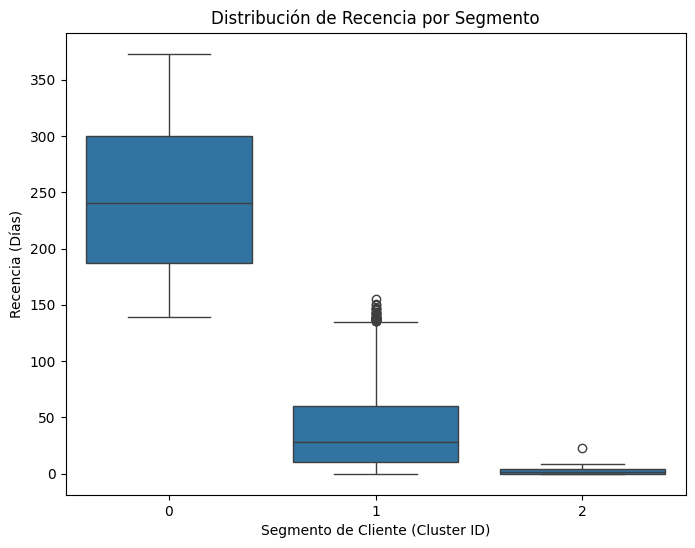

In [19]:
#grafica de recencia
 
plt.figure(figsize=(8, 6))

sns.boxplot(x='cluster_id', y='recency', data=df_rfm)

plt.title('Distribución de Recencia por Segmento')
plt.xlabel('Segmento de Cliente (Cluster ID)')
plt.ylabel('Recencia (Días)')
plt.show()


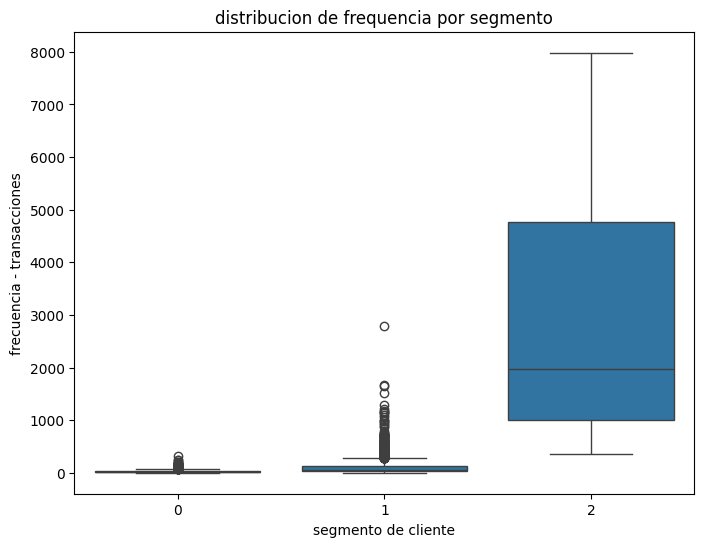

In [20]:
#gráfica de frecuencia

plt.figure(figsize=(8,6))
sns.boxplot(x='cluster_id', y='frequency', data=df_rfm)
plt.title('distribucion de frequencia por segmento')
plt.xlabel('segmento de cliente')
plt.ylabel("frecuencia - transacciones")
plt.show()



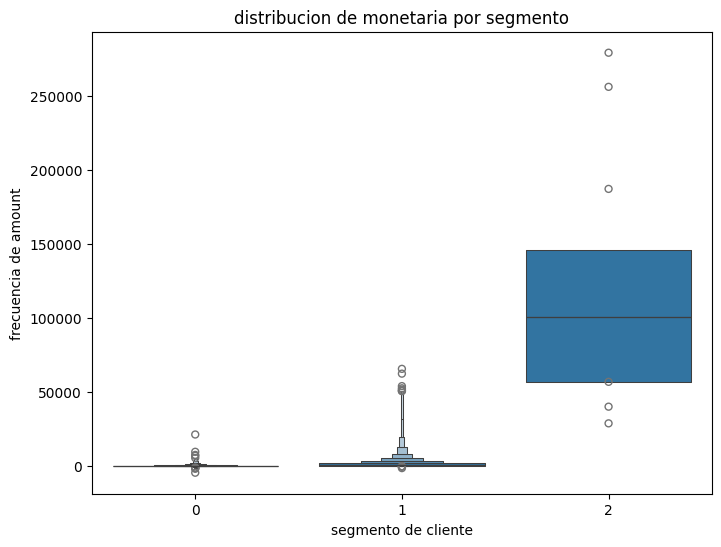

In [21]:
#gráfica de amount

plt.figure(figsize=(8,6))
sns.boxenplot(x='cluster_id', y='amount', data=df_rfm)
plt.title("distribucion de monetaria por segmento")
plt.xlabel("segmento de cliente")
plt.ylabel("frecuencia de amount")
plt.show()

In [22]:
df_rfm.to_csv('dataset/rfm_data.csv', index=False)

In [24]:
ssd = [] # Suma de los cuadrados de las distancias (Inercia)
silhouette_scores = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    # Entrenar el modelo
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(rfm_scaled)
    
    # método codo
    ssd.append(kmeans.inertia_)
    
    # 2. Análisis Silueta
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)


Text(0, 0.5, 'Inercia (SSD)')

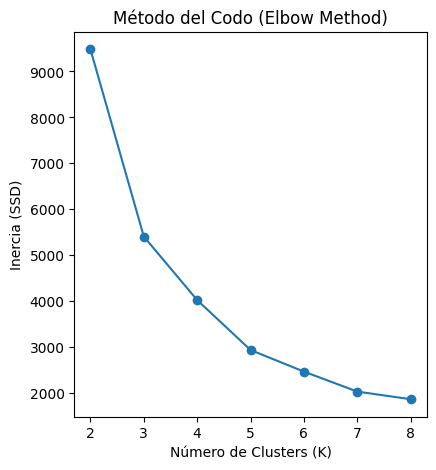

In [25]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) # 1 fila, 2 columnas, gráfico 1
plt.plot(range_n_clusters, ssd, marker='o')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (SSD)')

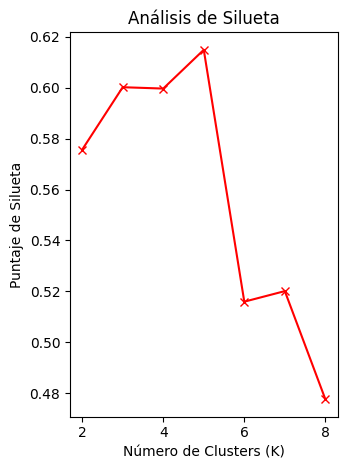

In [28]:
# --- Graficar el Análisis de Silueta ---
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, gráfico 2
plt.plot(range_n_clusters, silhouette_scores, marker='x', color='red')
plt.title('Análisis de Silueta')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Puntaje de Silueta')

plt.tight_layout() # Ajusta los gráficos para que no se superpongan
plt.savefig('justificacion_clusters.png')
plt.show()

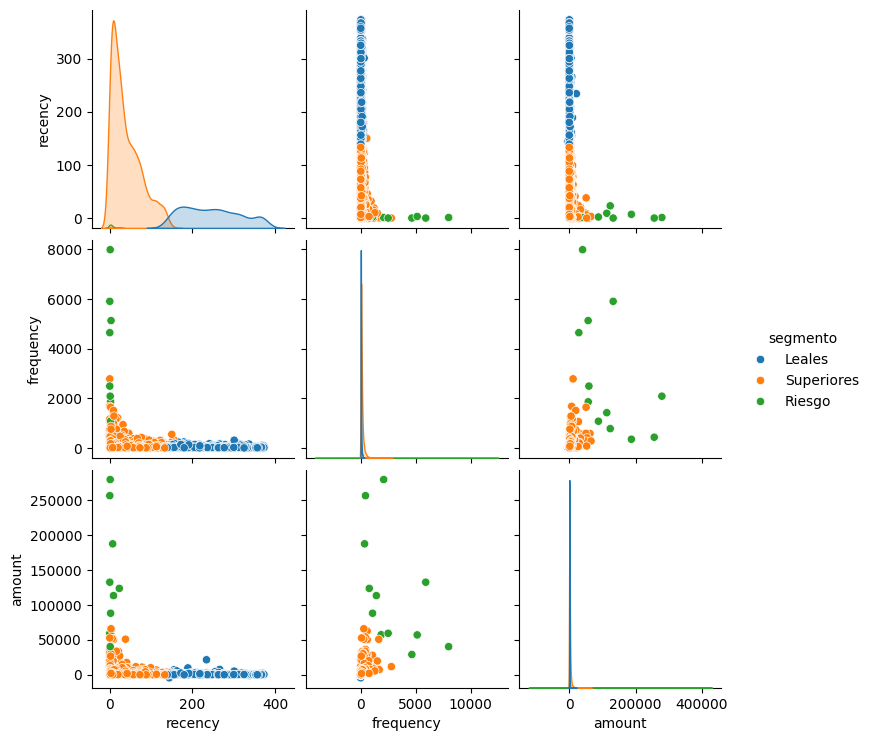

In [30]:
#pairplot

df_rfm['segmento'] = df_rfm['cluster_id'].map({
    1: 'Superiores', # El que gasta mucho (VIP)
    0: 'Leales',     # El intermedio
    2: 'Riesgo'      # El que gasta poco y hace mucho que no viene
})

# --- El Pairplot ---
# 'hue' es lo que le da color a los puntos (nuestros segmentos)
# 1. Asigna el resultado del pairplot a la variable 'fig'
fig = sns.pairplot(df_rfm, hue='segmento', vars=['recency', 'frequency', 'amount'])

# 2. Usa esa variable para guardar el archivo
fig.savefig('pairplot_segmentos.png')

# 3. Muestra el gráfico (opcional, pero ayuda a la revisión)
plt.show()